# **Student Training Program on AIML**
### MODULE 3: CLASSIFICATION-1
### LAB-2 : Implementing KNN from scratch and visualize Algorithm performance

---

# **Section 1: Implementing KNN**

In the last lab we had started discussing about KNN or K Nearest Neighbour method for clasification. We used the pre-built scikit-learn library for KNN. Now let's see how to implement this algorithm from scratch  

In [124]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn import preprocessing
from collections import Counter

def predict(X_train, y_train, X_test, k):
    distances = []

    for i in range(len(X_train)):
        distance = np.sqrt(
            np.sum(np.square(X_test - X_train[i, :]))
        )
        distances.append((
            distance,
            X_train[i, :],
            y_train[i]
        ))
    distances = sorted(distances, key=lambda x: x[0])
    return distances[:k]

def k_nearest_neighbor(X_train, y_train, X_test, k):
    assert k <= len(X_train), "[!] K cannot be larger than number of samples."
    all_neighbors = []

    for i in range(len(X_test)):
        neighbors = predict(
            X_train,
            y_train,
            X_test[i, :],
            k
        )
        all_neighbors.append(neighbors)

    return all_neighbors

**Note** : If k = 1 then the algorithm will simply return the label of the nearest neighbour. When we give k > 1 the most common label out of the given labels in the k neighbours will be selected.The code for 1 NN is given as follows and does not have to be so complicated.

In [125]:
def NN1(traindata, trainlabel, query):
  diff  = traindata - query
  sq = diff*diff
  dist = sq.sum(1)
  label = trainlabel[np.argmin(dist)]
  return label

def Accuracy(gtlabel, predlabel):
  assert len(gtlabel)==len(predlabel), "Length of the groundtruth labels and predicted labels should be the same"
  correct = (gtlabel==predlabel).sum()
  return correct/len(gtlabel)

## Section 1.1 - Iris Dataset
Let's try it out on Iris Dataset present in the scikit learn library

In [126]:
neighbors = k_nearest_neighbor(
    X_train,
    y_train,
    X_test,
    3
)

for i, sample_neighbors in enumerate(neighbors):
    print(f"\nTest Sample {i+1}")

    for j, neighbor in enumerate(sample_neighbors):
        print(f"\nNeighbor {j+1}")
        print("Distance :", neighbor[0])
        print("Features :", neighbor[1])
        print("Class    :", neighbor[2])


Test Sample 1

Neighbor 1
Distance : 0.08573019158118866
Features : [ 0.98493451 -0.12481785]
Class    : 1

Neighbor 2
Distance : 0.1514616929421302
Features : [ 0.8908152  -0.03446444]
Class    : 1

Neighbor 3
Distance : 0.21726701395354908
Features : [ 0.81509524 -0.37203706]
Class    : 1

Test Sample 2

Neighbor 1
Distance : 0.15447290654763407
Features : [-2.28085963  0.74133045]
Class    : 0

Neighbor 2
Distance : 0.4362830518215032
Features : [-2.20948924  0.43666314]
Class    : 0

Neighbor 3
Distance : 0.45158802144236404
Features : [-2.54308575  0.57941002]
Class    : 0

Test Sample 3

Neighbor 1
Distance : 0.3588943890295039
Features : [3.49992004 0.4606741 ]
Class    : 2

Neighbor 2
Distance : 0.495012708924608
Features : [3.39703874 0.55083667]
Class    : 2

Neighbor 3
Distance : 0.8382879837080517
Features : [3.07649993 0.68808568]
Class    : 2

Test Sample 4

Neighbor 1
Distance : 0.15040485232482753
Features : [ 0.8908152  -0.03446444]
Class    : 1

Neighbor 2
Distance :

In [127]:
from sklearn.datasets import load_iris
data = load_iris()
df = pd.DataFrame(data=data.data, columns=data.feature_names)
df["target"] = data.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [128]:
X = np.array(df[['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']])
y = np.array(df['target'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=17)

neighbors = k_nearest_neighbor(
    X_train,
    y_train,
    X_test,
    3
)

for i, sample_neighbors in enumerate(neighbors):

    for j, neighbor in enumerate(sample_neighbors):
        print(f"\nNeighbor {j+1}")
        print("Distance :", neighbor[0])
        print("Features :", neighbor[1])
        print("Class    :", neighbor[2])


Neighbor 1
Distance : 0.3464101615137753
Features : [5.4 3.7 1.5 0.2]
Class    : 0

Neighbor 2
Distance : 0.3872983346207418
Features : [5.5 4.2 1.4 0.2]
Class    : 0

Neighbor 3
Distance : 0.41231056256176646
Features : [5.1 3.7 1.5 0.4]
Class    : 0

Neighbor 1
Distance : 0.19999999999999973
Features : [6.1 3.  4.6 1.4]
Class    : 1

Neighbor 2
Distance : 0.24494897427831785
Features : [6.1 2.9 4.7 1.4]
Class    : 1

Neighbor 3
Distance : 0.33166247903553975
Features : [5.9 3.  4.2 1.5]
Class    : 1

Neighbor 1
Distance : 0.24494897427831822
Features : [6.9 3.1 5.1 2.3]
Class    : 2

Neighbor 2
Distance : 0.3605551275463989
Features : [6.5 3.  5.2 2. ]
Class    : 2

Neighbor 3
Distance : 0.360555127546399
Features : [6.9 3.1 5.4 2.1]
Class    : 2

Neighbor 1
Distance : 0.17320508075688815
Features : [5.6 2.7 4.2 1.3]
Class    : 1

Neighbor 2
Distance : 0.22360679774997935
Features : [5.6 3.  4.1 1.3]
Class    : 1

Neighbor 3
Distance : 0.26457513110645864
Features : [5.8 2.7 3.9 1.2

Voila! You have implemented your own version of the K-Nearest Neighbours algorithm, which works very well on the Iris Dataset. Congratulations!  

Now try out the sklearn implementation and compare your results.  

In [129]:
from sklearn.neighbors import KNeighborsClassifier

sklearn_knn = KNeighborsClassifier(n_neighbors=7)
sklearn_knn.fit(X_train,y_train)
sklearn_predictions = sklearn_knn.predict(X_test)
accuracy = accuracy_score(y_test, sklearn_predictions)
print("The accuracy of Sklearn classifier is {} %".format(100*accuracy))

The accuracy of Sklearn classifier is 94.0 %


##  Section 1.2: Weighted NN
For KNN, If k is too small, the algorithm would be more sensitive to outliers. If k is too large, then the neighborhood may include too many points from other classes. We also take the label with max votes in the neighbourhood. Another choice can be that instead of giving equal weights to each of the neighbours we can give weighted points in the neighbourhood. So we weigh points by the inverse of their distance. Therefore, closer points will be given a higher priority as compared to the far off points.

An easy way to implement this is by specifying the 'weights' parameter as distance when defining the sklearn KNN function. For more information go through this [site](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)

In [ ]:
## TASK
## Modify the KNN function you wrote to return all the K-nearest neighbours along with their distances,
## instead of just the output that was most common. You don't need to find out accuracy, just modify the function
## and return the k-nearest neighbours and distances.

# **Section 2: Visualizing Data**  

We will look into something called **Voronoi** diagrams.  

**Note**: Ideally, we should perform data visualization to see what the data looks like before we apply any Machine Learning algorithm.  Only for the purpose of this lab session, we're explaining it after you've applied KNN.

### Voronoi Diagrams  

In simple terms, Voronoi diagrams help you to visualize the dataset by partioning the plane into regions that are close to a given set of points. These regions are also called Voronoi cells.  

Note that the cells/regions depend on the Distance metric being used. One way of interpreting this is by understanding that the distance metric decides the degree to which a 'point' or 'seed' in the Voronoi diagram has influence.  For each seed there is a corresponding region, called a Voronoi cell, consisting of all points of the plane closer to that seed than to any other.

This [link](https://en.wikipedia.org/wiki/Voronoi_diagram#Illustration) provides a wonderful illustration of Voronoi plots for 20 points in two cases: (1) Using Euclidean distance, and (2) Using Manhattan distance.  



Since our Iris data is 4-dimensional (as it has 4 attributes), we need to convert into a form that can be represented in 2-D.   

While there are methods to visualize data higher than 2-dimensions, that is beyond scope for now.  

For simplicity, we just take the first two columns of the iris dataset attributes and observe the Voronoi diagram generated for that.  
Alternatively, one can also perform PCA (Principal Component Analysis), to reduce the 4D data to just two dimensions.

In [130]:
#@title Plotting Voronoi regions
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, voronoi_plot_2d

def voronoi_finite_polygons_2d(vor, radius=None):
    """
    Reconstruct infinite voronoi regions in a 2D diagram to finite
    regions.

    Parameters
    ----------
    vor : Voronoi
        Input diagram
    radius : float, optional
        Distance to 'points at infinity'.

    Returns
    -------
    regions : list of tuples
        Indices of vertices in each revised Voronoi regions.
    vertices : list of tuples
        Coordinates for revised Voronoi vertices. Same as coordinates
        of input vertices, with 'points at infinity' appended to the
        end.

    """

    if vor.points.shape[1] != 2:
        raise ValueError("Requires 2D input")

    new_regions = []
    new_vertices = vor.vertices.tolist()

    center = vor.points.mean(axis=0)
    if radius is None:
        radius = np.ptp(vor.points, axis=0).max()

    all_ridges = {}
    for (p1, p2), (v1, v2) in zip(vor.ridge_points, vor.ridge_vertices):
        all_ridges.setdefault(p1, []).append((p2, v1, v2))
        all_ridges.setdefault(p2, []).append((p1, v1, v2))

    for p1, region in enumerate(vor.point_region):
        vertices = vor.regions[region]

        if all(v >= 0 for v in vertices):
            # finite region
            new_regions.append(vertices)
            continue

        # reconstruct a non-finite region
        ridges = all_ridges[p1]
        new_region = [v for v in vertices if v >= 0]

        for p2, v1, v2 in ridges:
            if v2 < 0:
                v1, v2 = v2, v1
            if v1 >= 0:
                # finite ridge: already in the region
                continue

            # Compute the missing endpoint of an infinite ridge

            t = vor.points[p2] - vor.points[p1] # tangent
            t /= np.linalg.norm(t)
            n = np.array([-t[1], t[0]])  # normal

            midpoint = vor.points[[p1, p2]].mean(axis=0)
            direction = np.sign(np.dot(midpoint - center, n)) * n
            far_point = vor.vertices[v2] + direction * radius

            new_region.append(len(new_vertices))
            new_vertices.append(far_point.tolist())

        # sort region counterclockwise
        vs = np.asarray([new_vertices[v] for v in new_region])
        c = vs.mean(axis=0)
        angles = np.arctan2(vs[:,1] - c[1], vs[:,0] - c[0])
        new_region = np.array(new_region)[np.argsort(angles)]

        # finish
        new_regions.append(new_region.tolist())

    return new_regions, np.asarray(new_vertices)

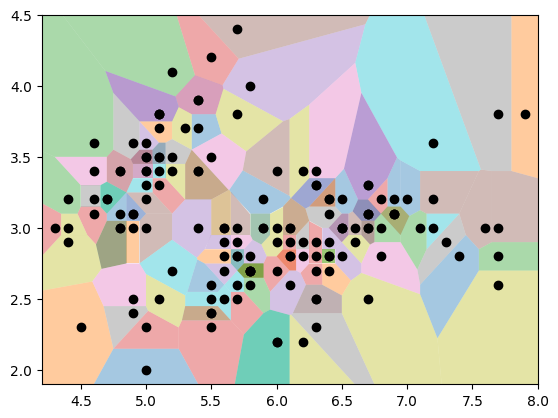

In [131]:
## Plotting Voronoi regions for the Iris dataset

points = []
xpts = np.array(df['sepal length (cm)'])
ypts = np.array(df['sepal width (cm)'])
for i in range(len(xpts)):
  points.append([xpts[i],ypts[i]])
# print(points)
points = np.array(points)
# compute Voronoi tesselation
vor = Voronoi(points)

regions,vertices = voronoi_finite_polygons_2d(vor)

for region in regions:
    polygon = vertices[region]
    plt.fill(*zip(*polygon), alpha=0.4)

plt.plot(points[:,0], points[:,1], 'ko')
plt.xlim(vor.min_bound[0] - 0.1, vor.max_bound[0] + 0.1)
plt.ylim(vor.min_bound[1] - 0.1, vor.max_bound[1] + 0.1)

plt.show()

## Section 2.2: Understanding Decision Boundaries  
So you have seen the Voronoi diagram of the dataset, implemented KNN, and also seen your algorithm's performance in terms of accuracy? Impressive!  
Wouldn't it also be great to know how exactly these 'votes' or neighbours are decided through some kind of visualization?  


### Decision Boundary

While the Voronoi diagram gave us a good idea of the points present in our dataset, to understand how KNN performed on our dataset we can plot decision boundaries. Decision boundaries, as the name suggests, divide the plane into different regions of classification.  

Note that here again, for simplicity, we have only considered first two attributes of the DataFrame (ie, Sepal Length and Sepal Width).  

In [132]:
from matplotlib.colors import ListedColormap
import seaborn as sns


def decision_boundary_plot(x_dec,y_dec,k):
  h = .02
  n = len(set(y_dec))
  cmap_light = ListedColormap(['pink', 'green', 'cyan','yellow'][:n])
  cmap_bold = ['pink', 'darkgreen', 'blue','yellow'][:n]

  for weights in ['uniform', 'distance']:
      clf = KNeighborsClassifier(n_neighbors=k, weights=weights)
      clf.fit(x_dec, y_dec)

      x_min, x_max = x_dec[:, 0].min() - 1, x_dec[:, 0].max() + 1
      y_min, y_max = x_dec[:, 1].min() - 1, x_dec[:, 1].max() + 1
      xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                          np.arange(y_min, y_max, h))
      Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
      Z = Z.reshape(xx.shape)
      plt.figure(figsize=(8, 6))
      plt.contourf(xx, yy, Z, cmap=cmap_light)

      sns.scatterplot(x=x_dec[:, 0], y=x_dec[:, 1], hue=y_dec,
                      palette=cmap_bold, alpha=1.0, edgecolor="black")
      plt.xlim(xx.min(), xx.max())
      plt.ylim(yy.min(), yy.max())
      plt.title("Multi-Classification (k = %i, weights = '%s')"% (k, weights))

  plt.show()


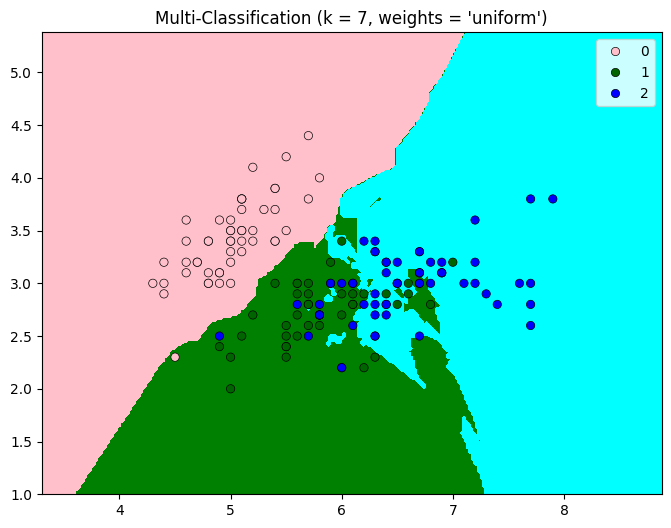

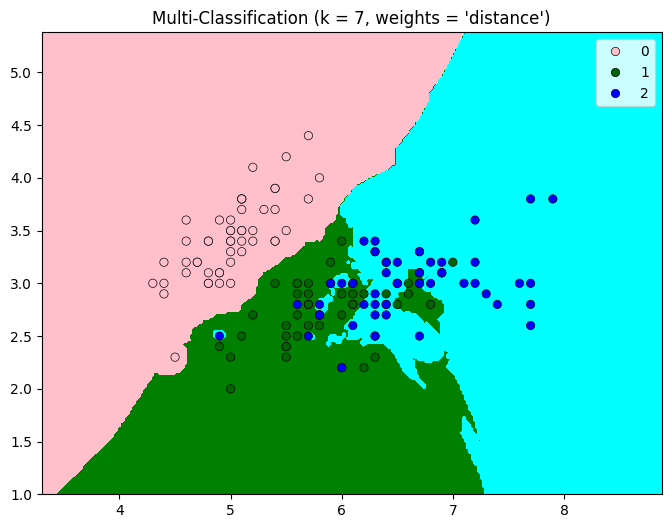

In [133]:
X = np.array(X)
y = np.array(y)

x_pts = X[:, :2]
y_pts = y
decision_boundary_plot(x_pts,y_pts,7)

In [ ]:
## TASK-2
## In the above cells, we saw the Voronoi diagram of the data and plotted the KNN decision boundaries
## by only considering two attributes of the dataset. You must be already familiar with PCA.
## Apply PCA on the dataset above to reduce it to two dimensions.
## Plot the Voronoi diagram and Decision boundaries after that.

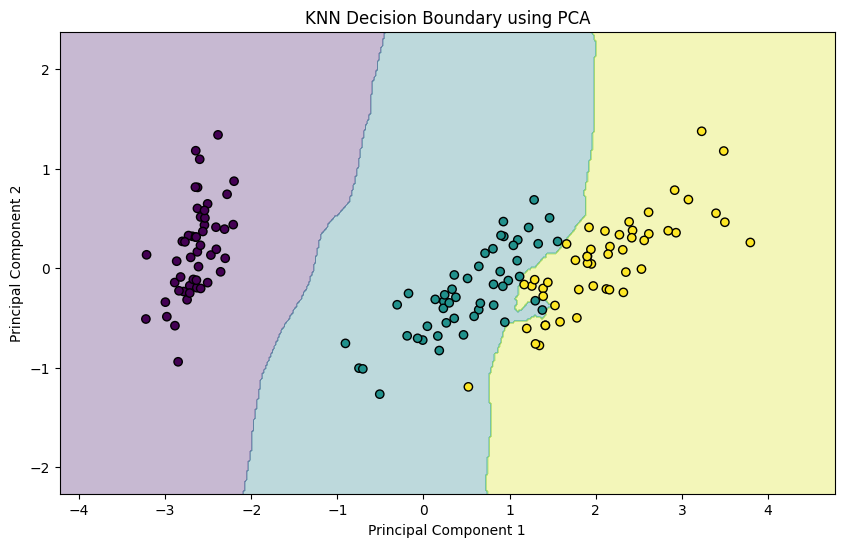

In [134]:
# My Code:

from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

iris = load_iris()

X = iris.data
y = iris.target
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.33,
    random_state=42
)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
predictions = knn.predict(X_test)

x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)
Z = knn.predict(
    np.c_[xx.ravel(), yy.ravel()]
)
Z = Z.reshape(xx.shape)
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3)
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    edgecolor='k'
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("KNN Decision Boundary using PCA")
plt.show()

## Section 2.3: Confusion Matrix  
In classification problems, a confusion matrix, also known as an error matrix, is a table that allows visualization of the performance of an algorithm, typically a supervised learning one. Each row of the matrix represents the instances in an actual class while each column represents the instances in a predicted class.

[[19  0  0]
 [ 0 15  0]
 [ 0  0 16]]
Predicted   0   1   2  All
True                      
0          19   0   0   19
1           0  15   0   15
2           0   0  16   16
All        19  15  16   50


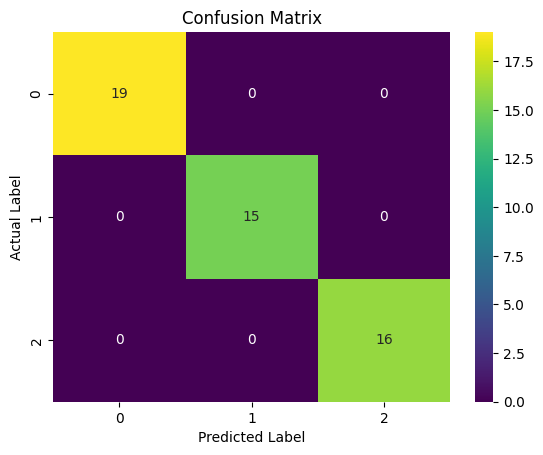

In [135]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import metrics
import numpy as np

y_true = np.array(y_test).ravel()
y_pred = np.array(predictions).ravel()
cnf_matrix = confusion_matrix(y_true, y_pred)

print(cnf_matrix)
print(
    pd.crosstab(
        y_true,
        y_pred,
        rownames=['True'],
        colnames=['Predicted'],
        margins=True
    )
)

sns.heatmap(
    pd.DataFrame(cnf_matrix),
    annot=True,
    cmap="viridis",
    fmt='g'
)

plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

## Section 2.4: Classification Report

Precision, Recall, and F1-Score are other metrics besides accuracy that one might look for in an algorithm.  Depending on the use-case, one might consider one metric more important than the other.  

Note: *T-> True, F->False, P->Positive, N->Negative*
    
Mathematically, Accuracy is :  

$Accuracy = \frac{TP+TN}{TP+TN+FP+FN}$  

**Precision**: The accuracy of positive predictions


$Precision = \frac{TP}{TP+FP}$

**Recall**:Fraction of positives that were correctly identified


$Recall = \frac{TP}{TP+FN}$


**F1-score**: Harmonic mean of precision and recall  


$F1 = \frac{2*Precision*Recall}{Precision+Recall} = \frac{2*TP}{2*TP+FP+FN}$  



In [137]:
from sklearn.metrics import classification_report
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        15
           2       1.00      1.00      1.00        16

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



### **Car Evaluation Dataset**

In [58]:
# Upload the Car evaluation data CSV file that has been shared with you.
# Run this cell, click on the 'Choose files' button and upload the file.
from google.colab import files
uploaded = files.upload()

Saving car_evaluation.csv to car_evaluation.csv


In [138]:
import pandas as pd

car_df = pd.read_csv(
    "car_evaluation.csv",
    header=None
)

car_df.columns = [
    'buying',
    'maint',
    'doors',
    'persons',
    'lug_boot',
    'safety',
    'decision'
]

car_df.head()

,buying,maint,doors,persons,lug_boot,safety,decision
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [139]:
for x in car_df.columns:
  # print(x)
  le = preprocessing.LabelEncoder()
  le.fit(car_df[x])
  car_df[x]=le.transform(car_df[x])

car_df

,buying,maint,doors,persons,lug_boot,safety,decision
0,3,3,0,0,2,1,2
1,3,3,0,0,2,2,2
2,3,3,0,0,2,0,2
3,3,3,0,0,1,1,2
4,3,3,0,0,1,2,2
...,...,...,...,...,...,...,...
1723,1,1,3,2,1,2,1
1724,1,1,3,2,1,0,3
1725,1,1,3,2,0,1,2
1726,1,1,3,2,0,2,1


In [140]:
dataset = car_df.values
X = dataset[:,0:6]
y = np.array(dataset[:,6])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=19)

In [141]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
predictions = knn.predict(X_test)
score = accuracy_score(y_test, predictions)
print("The accuracy of the classifier on Car evaluation dataset is {:.2f} %".format(100*score))

The accuracy of the classifier on Car evaluation dataset is 91.91 %


In [ ]:
## TASK-3
## Plot a Confusion Matrix for the results of the Car evaluation dataset

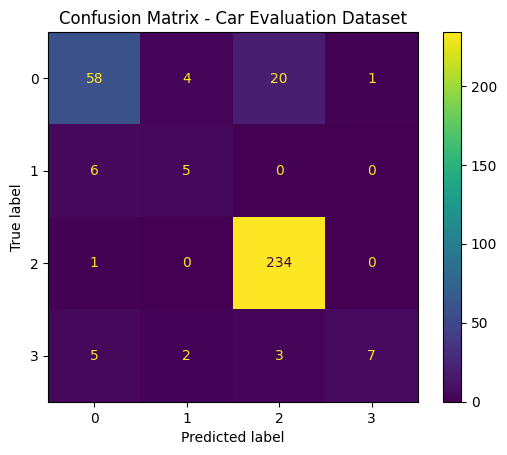

In [142]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

encoder = LabelEncoder()
car_encoded = car_df.copy()

for column in car_encoded.columns:
    car_encoded[column] = encoder.fit_transform(car_encoded[column])

X = car_encoded.drop('decision', axis=1)
y = car_encoded['decision']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
predictions = knn.predict(X_test)

cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Car Evaluation Dataset")
plt.show()

In [ ]:
## TASK-4
## Print a Classification Report for the results of the Car evaluation dataset

In [143]:
from sklearn.metrics import classification_report
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.83      0.70      0.76        83
           1       0.45      0.45      0.45        11
           2       0.91      1.00      0.95       235
           3       0.88      0.41      0.56        17

    accuracy                           0.88       346
   macro avg       0.77      0.64      0.68       346
weighted avg       0.87      0.88      0.87       346



In [ ]:
## TASK-5
## Plot the Decision boundary diagram for the classifier of the Car evaluation dataset

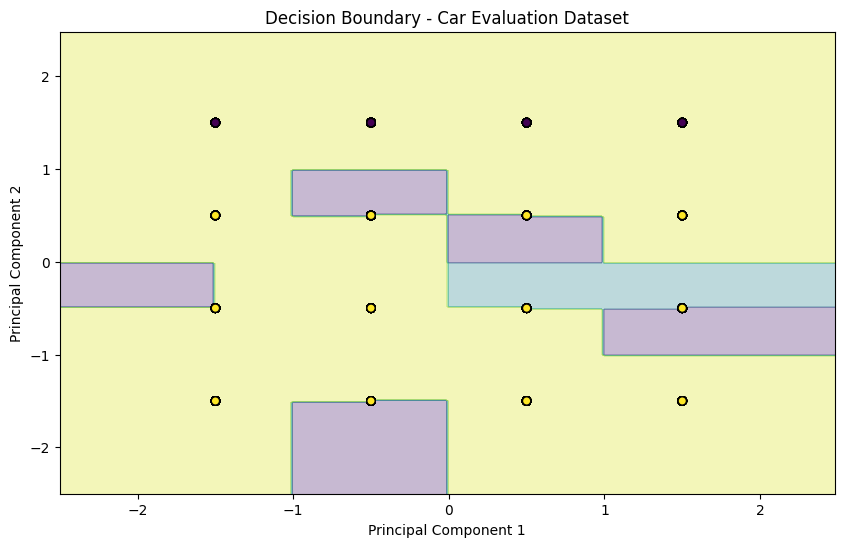

In [144]:
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import numpy as np

encoder = LabelEncoder()
car_encoded = car_df.copy()

for column in car_encoded.columns:
    car_encoded[column] = encoder.fit_transform(car_encoded[column])

X = car_encoded.drop('decision', axis=1)
y = car_encoded['decision']
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42
)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)
Z = knn.predict(
    np.c_[xx.ravel(), yy.ravel()]
)
Z = Z.reshape(xx.shape)
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3)

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    edgecolor='k'
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Decision Boundary - Car Evaluation Dataset")
plt.show()

In [ ]:
## TASK-6
## Plot the Voronoi diagram for the classifier of the Car evaluation dataset

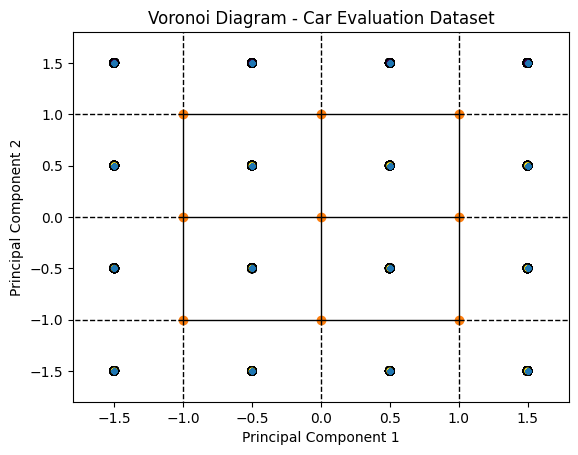

In [145]:
from scipy.spatial import Voronoi, voronoi_plot_2d
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

encoder = LabelEncoder()
car_encoded = car_df.copy()

for column in car_encoded.columns:
    car_encoded[column] = encoder.fit_transform(car_encoded[column])

X = car_encoded.drop('decision', axis=1)
y = car_encoded['decision']
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
vor = Voronoi(X_pca)
fig = voronoi_plot_2d(vor)

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    edgecolor='k'
)
plt.title("Voronoi Diagram - Car Evaluation Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

## **Homework Assignment: Exploring Distance Metrics and KNN**

---

### **Problem 1: Implementing Custom Distance Metrics**

In this exercise, you'll implement distance metrics from scratch to deepen your understanding.

**Task 1.1:** Implement the Minkowski distance formula without using any library functions (except basic numpy operations).

Recall that Minkowski distance is defined as:

$$d(x, x') = \left(\sum_{j=1}^{D} |x_j - x'_j|^p\right)^{1/p}$$

where $p$ is a parameter. When $p=1$, it's Manhattan distance, and when $p=2$, it's Euclidean distance.

In [146]:
## HOMEWORK TASK 1.1
## Implement the Minkowski distance function below
## Test it with p=1 (should match Manhattan) and p=2 (should match Euclidean)
## Expected number of lines: 3-5

from scipy.spatial import distance
def minkowski_distance(x1, x2, p):

    return np.sum(np.abs(x1 - x2) ** p) ** (1 / p)

x_1 = np.array([1, 2, 3])
x_2 = np.array([4, 6, 8])

print("Minkowski distance (p=1):", minkowski_distance(x_1, x_2, 1))
print("Manhattan distance:", distance.cityblock(x_1, x_2))
print()
print("Minkowski distance (p=2):", minkowski_distance(x_1, x_2, 2))
print("Euclidean distance:", distance.euclidean(x_1, x_2))

Minkowski distance (p=1): 12.0
Manhattan distance: 12

Minkowski distance (p=2): 7.0710678118654755
Euclidean distance: 7.0710678118654755


---

### **Problem 2: Visualizing Decision Boundaries**

Understanding how KNN makes predictions is crucial. In this exercise, you'll visualize decision boundaries for different values of K.

**Task 2.1:** Create a function that visualizes the decision boundary of a KNN classifier on 2D data.

**Hint:** You'll need to:
1. Create a mesh grid covering the feature space
2. Train a KNN classifier
3. Predict the class for each point in the mesh
4. Plot the results using `plt.contourf()` for the decision boundary
5. Overlay the training data points

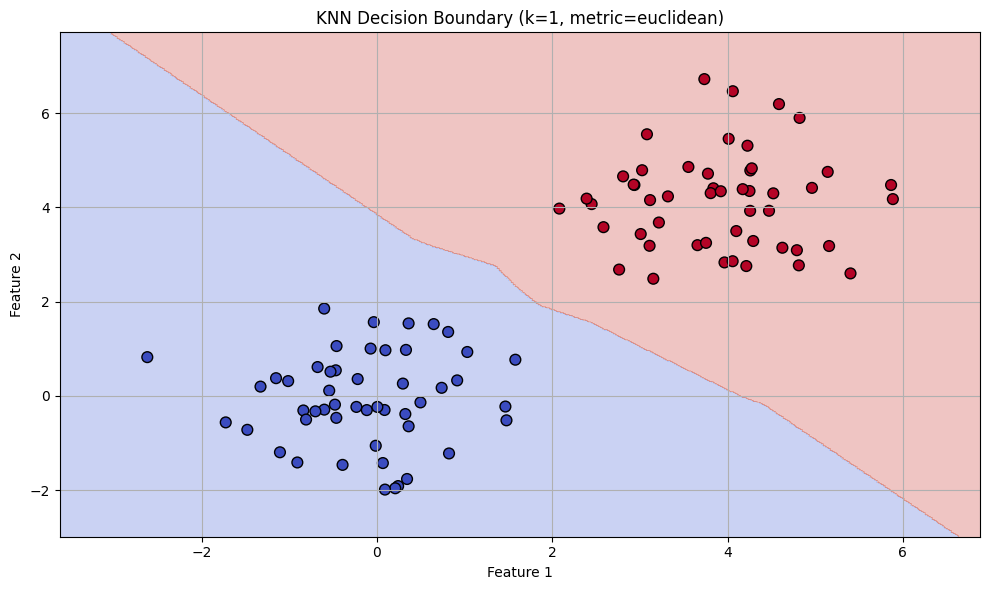

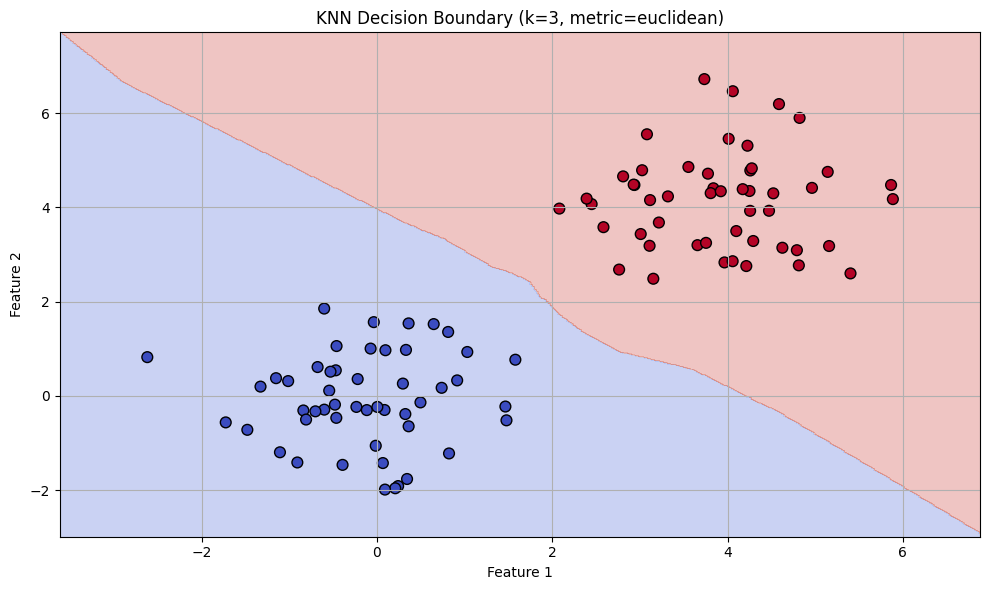

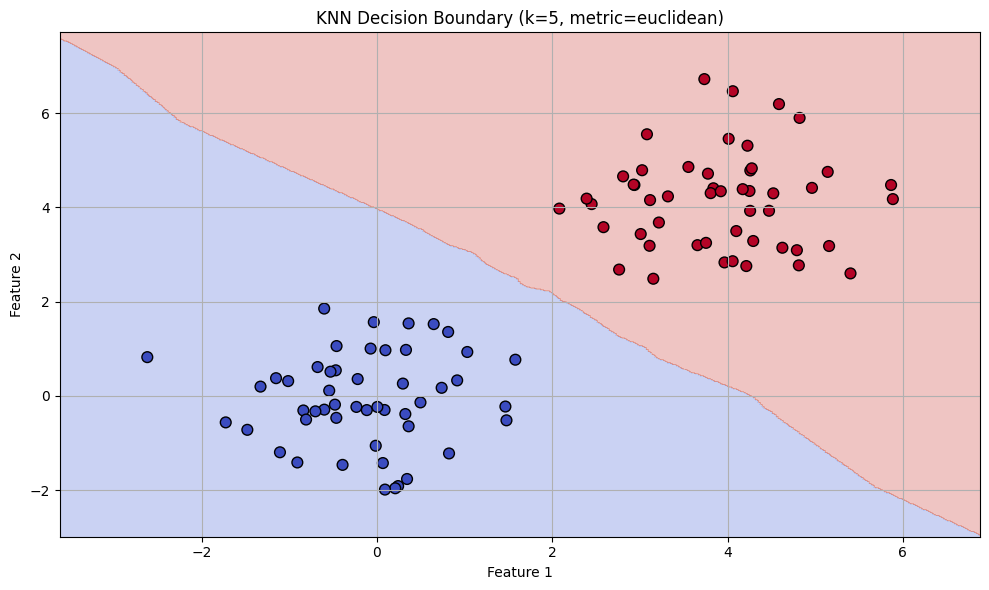

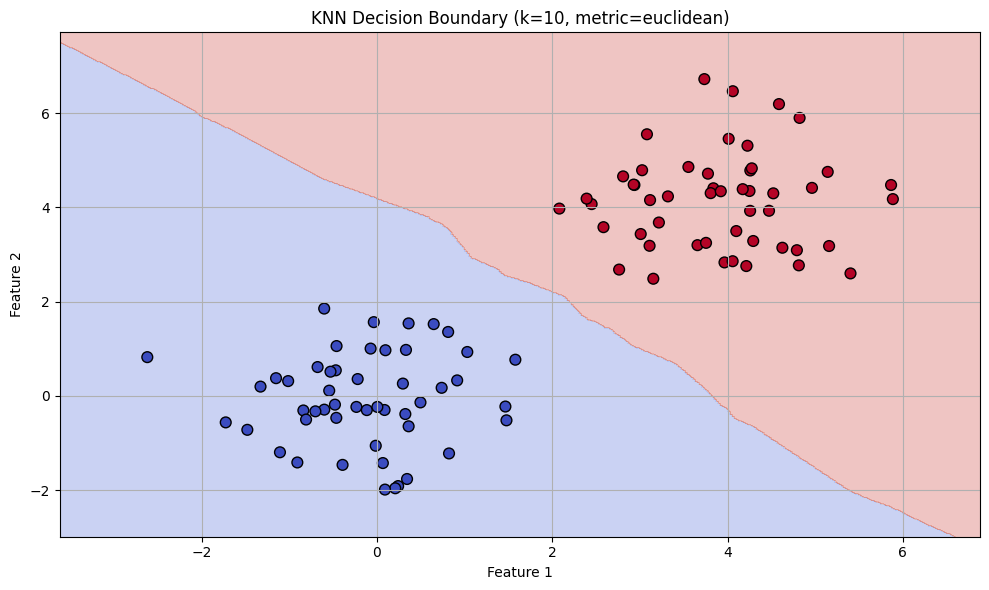

In [147]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

def generate_synth_data(n):
    np.random.seed(42)
    class_0 = np.random.randn(n, 2) + [0, 0]
    class_1 = np.random.randn(n, 2) + [4, 4]
    X = np.vstack((class_0, class_1))
    y = np.array([0] * n + [1] * n)
    return X, y

def plot_decision_boundary(X, y, k_value, metric='euclidean'):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )
    knn = KNeighborsClassifier(
        n_neighbors=k_value,
        metric=metric
    )
    knn.fit(X, y)
    Z = knn.predict(
        np.c_[xx.ravel(), yy.ravel()]
    )
    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(10, 6))
    plt.contourf(
        xx,
        yy,
        Z,
        alpha=0.3,
        cmap=plt.cm.coolwarm
    )
    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        edgecolor='k',
        cmap=plt.cm.coolwarm,
        s=60
    )
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(
        f'KNN Decision Boundary (k={k_value}, metric={metric})'
    )
    plt.grid(True)
    plt.tight_layout()
    plt.show()

n = 50
pts, tgts = generate_synth_data(n)

for k in [1, 3, 5, 10]:
    plot_decision_boundary(
        pts,
        tgts,
        k
    )

**Discussion Questions:**
1. What happens to the decision boundary as K increases? Is it smoother or more irregular?
2. Which K value seems to generalize better without overfitting?
3. Try changing the metric to 'manhattan' - how does the boundary change?

---

### **Problem 3: Impact of Distance Metrics on High-Dimensional Data**

The "curse of dimensionality" affects distance metrics differently. Let's explore this phenomenon.

**Task 3.1:** Create a function that generates random high-dimensional data and compares how different distance metrics behave as dimensionality increases.

**Background:** In high dimensions, the ratio between the maximum and minimum distances between points tends to approach 1, making it harder to distinguish between near and far neighbors. This affects different metrics differently.

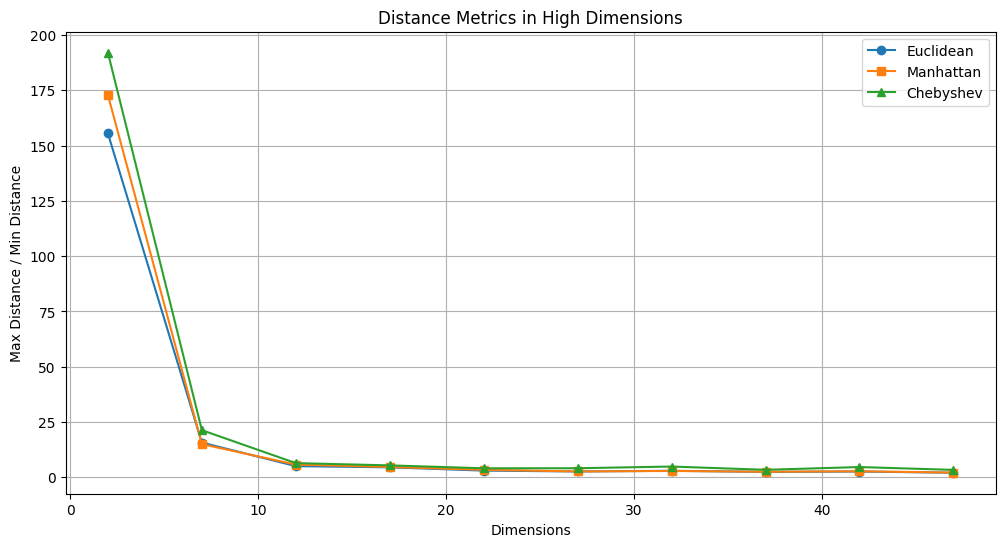

In [148]:
## HOMEWORK TASK 3.1
## Complete the function to analyze distance metrics in high dimensions
## Calculate the ratio of max distance to min distance for each metric

from scipy.spatial import distance
import numpy as np
import matplotlib.pyplot as plt


def analyze_distance_in_high_dims(max_dim=50, n_points=100):
    dimensions = range(2, max_dim + 1, 5)
    results = {
        'euclidean': [],
        'manhattan': [],
        'chebyshev': []
    }

    for dim in dimensions:
        points = np.random.randn(n_points, dim)
        euclidean_distances = distance.pdist(
            points,
            metric='euclidean'
        )
        manhattan_distances = distance.pdist(
            points,
            metric='cityblock'
        )
        chebyshev_distances = distance.pdist(
            points,
            metric='chebyshev'
        )
        euclidean_ratio = (
            np.max(euclidean_distances) /
            np.min(euclidean_distances)
        )
        manhattan_ratio = (
            np.max(manhattan_distances) /
            np.min(manhattan_distances)
        )
        chebyshev_ratio = (
            np.max(chebyshev_distances) /
            np.min(chebyshev_distances)
        )
        results['euclidean'].append(euclidean_ratio)
        results['manhattan'].append(manhattan_ratio)
        results['chebyshev'].append(chebyshev_ratio)

    plt.figure(figsize=(12, 6))
    plt.plot(
        dimensions,
        results['euclidean'],
        marker='o',
        label='Euclidean'
    )
    plt.plot(
        dimensions,
        results['manhattan'],
        marker='s',
        label='Manhattan'
    )
    plt.plot(
        dimensions,
        results['chebyshev'],
        marker='^',
        label='Chebyshev'
    )

    plt.xlabel('Dimensions')
    plt.ylabel('Max Distance / Min Distance')
    plt.title('Distance Metrics in High Dimensions')
    plt.legend()
    plt.grid(True)
    plt.show()

    return results

results = analyze_distance_in_high_dims()

### Questions to Think About and Answer
1. In the section on Decision boundaries, you must have seen that we ran the KNN algorithm twice: first with the _weights_ set to 'uniform' and then set to 'distance'. Find out the difference between these two.  
2. What do you think could be the drawbacks of using KNN ?

Answers:

[1 Ans] When the weights parameter in KNN is set to 'uniform', all the nearest neighbors contribute equally to the final prediction regardless of how far they are from the test point. This means that every neighbor gets the same voting power. On the other hand, when the weights parameter is set to 'distance', closer neighbors are given more importance than farther neighbors. In this approach, nearby data points have a stronger influence on the prediction, while distant points contribute less. Distance-based weighting often provides better accuracy because closer neighbors are usually more relevant to the test sample than farther ones.

[2 Ans] Although KNN is simple and easy to understand, it has several drawbacks. One major limitation is that it becomes computationally slow for large datasets because the algorithm calculates the distance between the test point and every training sample during prediction. KNN is also sensitive to noise and outliers, especially when the value of K is very small. Another important drawback is the curse of dimensionality, where distance measures become less meaningful in high-dimensional data, reducing the effectiveness of the algorithm. KNN also requires proper feature scaling because features with larger numeric ranges can dominate distance calculations. Additionally, it consumes high memory since the entire training dataset must be stored, and choosing the optimal value of K can be difficult because small K values may lead to overfitting while large K values may lead to underfitting.

### Useful Resources for further reading
1. Interactive KNN visualization, with class boundaries: http://vision.stanford.edu/teaching/cs231n-demos/knn/  
